In [1]:
names = open("names.txt",'r').read().splitlines()
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [2]:
a = names[:1][0]
b = names[:1][0][1:]

c = zip(names[:1][0],names[:1][0][1:])
list(c)

[('e', 'm'), ('m', 'm'), ('m', 'a')]

In [3]:
a = names[0]
b = names[0][1:]
b

'mma'

In [4]:
b = {}

for w in names:
    chs = ['<S>'] + list(w) + ['<E>']
    for chs12 in zip(chs,chs[1:]):
        biagram = chs12
        b[biagram] = b.get(biagram,0) + 1 # .get(biagram) biagram key'i varsa onu getirir + 1 Eğer yoksa döndürmek istediğin değeri döndürür o da 0
        
sorted(b.items(), key = lambda kv: kv[1], reverse = True) # key = listenin her elemanına verilen puan bu da lambda kv: kv[1] kv değerim de listenin her elemanı 



[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [5]:
import torch

In [6]:
big_string = ''.join(names) # Boşluksuz olarak birleştirir
char = sorted(list(set(big_string)))

stoi = {s:i for i,s in enumerate(char)} # char listesindeki her harfi sayıyla eşleştrip dict e kaydettik
stoi['<S>'] = 26
stoi['<E>'] = 27
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [7]:
stoi = {s:i+1 for i,s in enumerate(char)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [8]:
N = torch.zeros((27,27), dtype=torch.int32)

for w in names:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        biagram = (ch1,ch2)
        
        ch1_idx = stoi[ch1]
        ch2_idx = stoi[ch2]
        N[ch1_idx,ch2_idx] += 1 
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

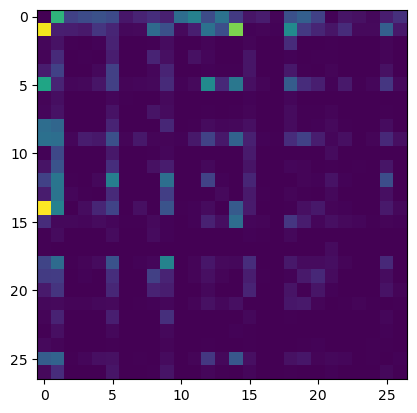

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)


(-0.5, 26.5, 26.5, -0.5)

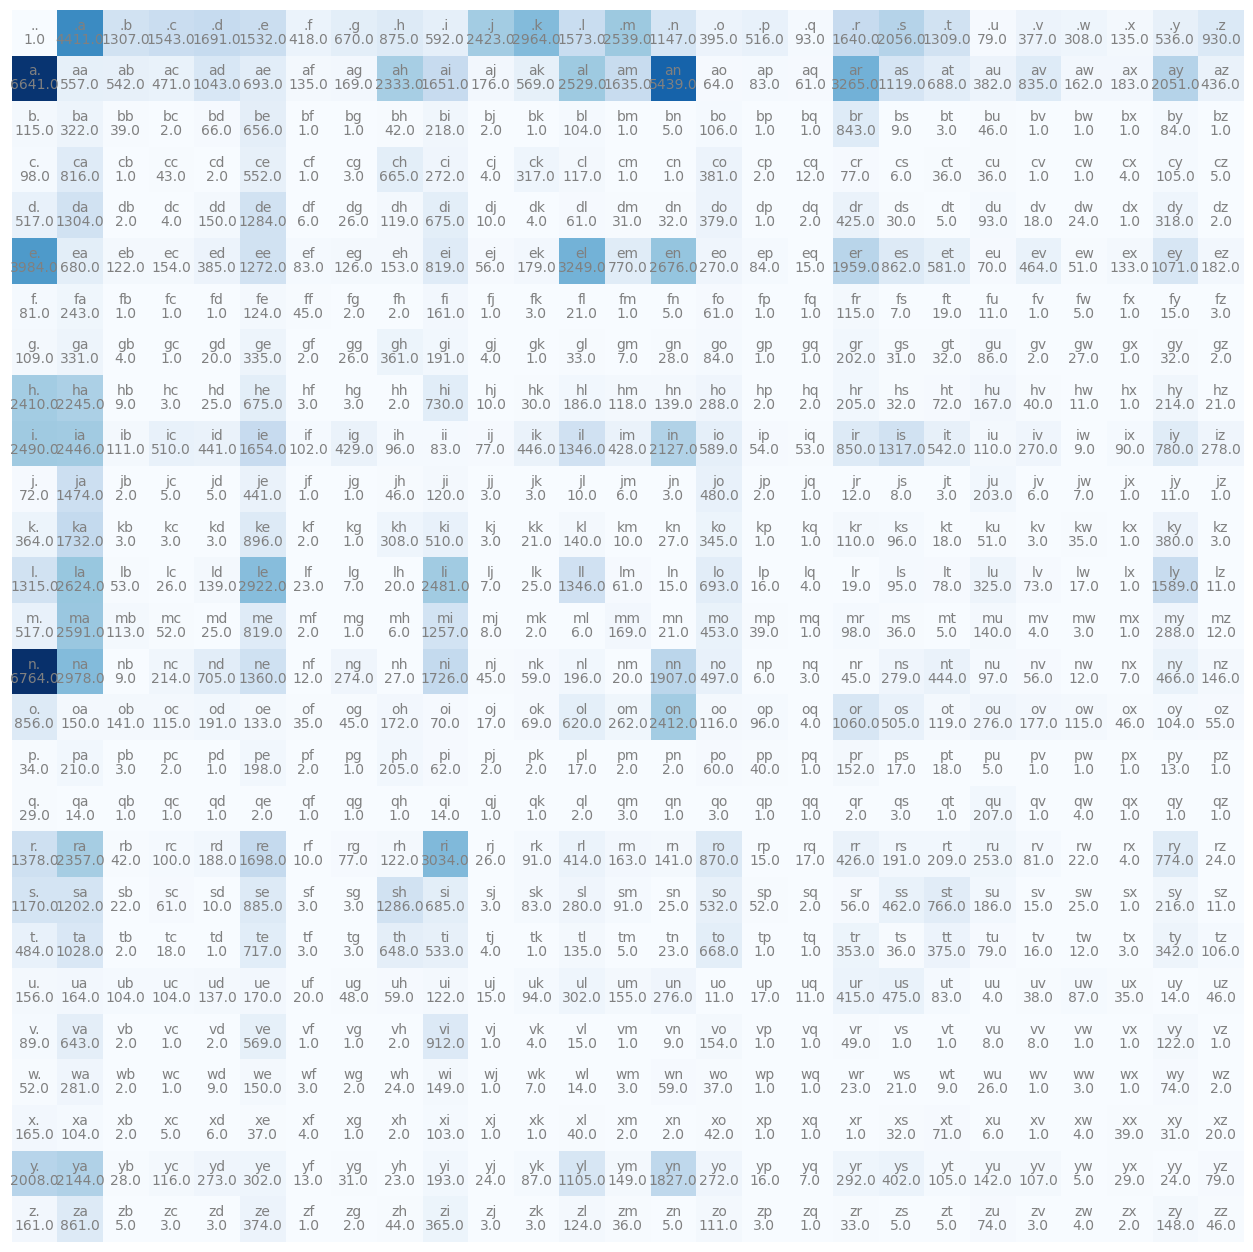

In [35]:
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis('off')

In [11]:
N[0].float() / N[0].float().sum()

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [12]:
g = torch.Generator().manual_seed(1)
r = torch.rand(1, generator=g)
r

tensor([0.7576])

In [14]:
a = N[0] / N[0].sum()
b = torch.multinomial(a, num_samples=1, replacement=True, generator=g).item()
b

16

In [34]:
N = torch.zeros((27,27), dtype=torch.float)

for w in names:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        biagram = (ch1,ch2)
        
        ch1_idx = stoi[ch1]
        ch2_idx = stoi[ch2]
        N[ch1_idx,ch2_idx] += 1.0

N = N + 1

In [16]:
N[0] = N[0] / N[0].sum()
N[0]

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [17]:
for row in range(len(N)):
    N[row] = N[row] / N[row].sum()
N

tensor([[0.0000e+00, 1.3767e-01, 4.0770e-02, 4.8138e-02, 5.2758e-02, 4.7794e-02,
         1.3018e-02, 2.0885e-02, 2.7284e-02, 1.8450e-02, 7.5610e-02, 9.2498e-02,
         4.9074e-02, 7.9231e-02, 3.5776e-02, 1.2300e-02, 1.6077e-02, 2.8720e-03,
         5.1166e-02, 6.4153e-02, 4.0833e-02, 2.4350e-03, 1.1738e-02, 9.5839e-03,
         4.1832e-03, 1.6702e-02, 2.9001e-02],
        [1.9596e-01, 1.6408e-02, 1.5966e-02, 1.3870e-02, 3.0751e-02, 2.0422e-02,
         3.9546e-03, 4.9579e-03, 6.8821e-02, 4.8694e-02, 5.1645e-03, 1.6763e-02,
         7.4605e-02, 4.8222e-02, 1.6048e-01, 1.8592e-03, 2.4199e-03, 1.7707e-03,
         9.6326e-02, 3.2994e-02, 2.0274e-02, 1.1244e-02, 2.4613e-02, 4.7514e-03,
         5.3711e-03, 6.0499e-02, 1.2838e-02],
        [4.3100e-02, 1.2136e-01, 1.4367e-02, 3.7807e-04, 2.4575e-02, 2.4764e-01,
         0.0000e+00, 0.0000e+00, 1.5501e-02, 8.2042e-02, 3.7807e-04, 0.0000e+00,
         3.8941e-02, 0.0000e+00, 1.5123e-03, 3.9698e-02, 0.0000e+00, 0.0000e+00,
         3.1834e-

(-0.5, 26.5, 26.5, -0.5)

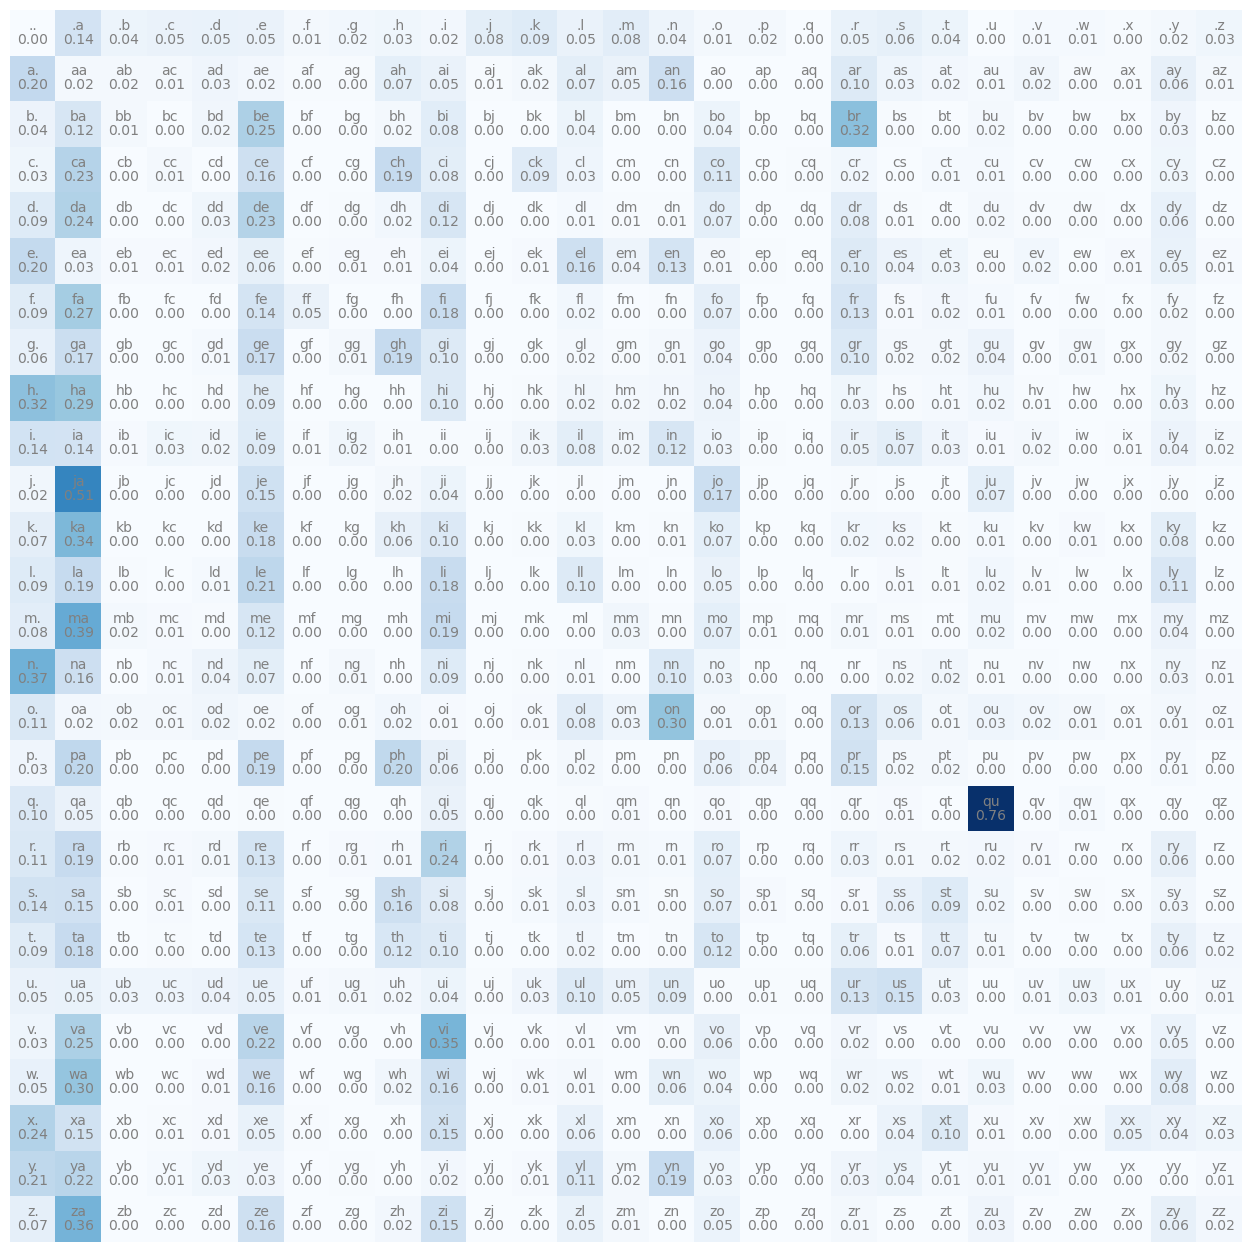

In [18]:
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, f"{N[i,j].item():.2f}", ha="center", va="top", color="gray")
plt.axis('off') 

In [38]:
P = N.float()
# P = (27,27)
# P.sum(1) = (27,)
# P.sum(1, keepdim=True) --> (27,1)

P = P / P.sum(1,keepdim=True)
torch.set_printoptions(sci_mode=False)
P

tensor([[    0.0000,     0.1376,     0.0408,     0.0481,     0.0527,     0.0478,
             0.0130,     0.0209,     0.0273,     0.0185,     0.0756,     0.0925,
             0.0491,     0.0792,     0.0358,     0.0123,     0.0161,     0.0029,
             0.0512,     0.0641,     0.0408,     0.0025,     0.0118,     0.0096,
             0.0042,     0.0167,     0.0290],
        [    0.1958,     0.0164,     0.0160,     0.0139,     0.0308,     0.0204,
             0.0040,     0.0050,     0.0688,     0.0487,     0.0052,     0.0168,
             0.0746,     0.0482,     0.1604,     0.0019,     0.0024,     0.0018,
             0.0963,     0.0330,     0.0203,     0.0113,     0.0246,     0.0048,
             0.0054,     0.0605,     0.0129],
        [    0.0430,     0.1205,     0.0146,     0.0007,     0.0247,     0.2455,
             0.0004,     0.0004,     0.0157,     0.0816,     0.0007,     0.0004,
             0.0389,     0.0004,     0.0019,     0.0397,     0.0004,     0.0004,
             0.31

In [20]:
g = torch.Generator().manual_seed(1)

for i in range(10):
    ix = 0 
    out = []
    while True:
        
        p = P[ix]
        #p = p / p.sum() #inefficent
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

h.
deres.
ena.
coge.
wicayayaranann.
linil.
rinilelivenayen.
tarilezz.
a.
vvicrushaleimme.


In [42]:
log_liklehood = 0.0
n = 0

for w in ['andrejq']:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        biagram = (ch1,ch2)
        
        ch1_idx = stoi[ch1]
        ch2_idx = stoi[ch2]
        prob = P[ch1_idx,ch2_idx]
        loss = torch.log(prob) * -1
        log_liklehood += loss
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f} : {loss:.4f}')
        
print(f'log_liklehood Average = {log_liklehood / n}')

# Neden Maximum Liklehood kullanıldı? Neden Loss = 1 - P(gerçek sonraki karakter | mevcut karakter) kullanılması?
# Loss = -log(P(gerçek sonraki karakter | mevcut karakter))
# Bunu datanın tamamına entegre etmemiz gerekli ki modelin loss'unu tam olarak ölçebilelim

# log(a*b*c) = log(a) + log(b) + log(c)


log_liklehood Average = 3.4834020137786865


In [51]:
xs, ys = [], []

for w in names[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        
        ch1_idx = stoi[ch1]
        ch2_idx = stoi[ch2]
        
        xs.append(ch1_idx)
        ys.append(ch2_idx)
    print(w)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

xs,ys

emma


(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [54]:
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27,27),generator=g)

In [55]:
import torch.nn.functional as F

x_enc = F.one_hot(xs, num_classes=27).float()
logits = x_enc @ w # (5,27) * (27,27) = (5,27)
counts = logits.exp()
probs = counts / counts.sum(1,keepdim=True)
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,